# 1. Import thư viện và các bảng dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import StrMethodFormatter

import os

input_dir='datasets/'
output_dir='output/'

orders=pd.read_csv(input_dir+'orders.csv')
order_items=pd.read_csv(input_dir+'order_items.csv')
payments=pd.read_csv(input_dir+'payments.csv')
customers=pd.read_csv(input_dir+'customers.csv')
returns=pd.read_csv(input_dir+'returns.csv')
review=pd.read_csv(input_dir+'reviews.csv')
products=pd.read_csv(input_dir+'products.csv')
geography=pd.read_csv(input_dir+'geography.csv')

C:\Users\Admin\AppData\Local\Temp\ipykernel_10892\3630385196.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items=pd.read_csv(input_dir+'order_items.csv')


# 2. Ghép các bảng với thông tin liên quan lại thành bảng master

In [2]:
master = pd.merge(orders, order_items, on='order_id', how='left')
master = pd.merge(master, payments, on='order_id', how='left')
master = pd.merge(master, customers, on='customer_id', how='left')

master = master.rename(columns={'zip_x': 'zip', 'payment_method_x': 'payment_method'})
master = master.drop(columns=['zip_y', 'payment_method_y'])

master = pd.merge(master, geography, on='zip', how='left')

master = master.rename(columns={'city_y': 'city'})
master = master.drop(columns=['city_x'])

master = pd.merge(master, returns, on=['order_id', 'product_id'], how='left', suffixes=('', '_ret'))
master = pd.merge(master, review, on=['order_id', 'product_id', 'customer_id'], how='left')

In [3]:
master['order_date'] = pd.to_datetime(master['order_date'])
snapshot_date=master['order_date'].max()+dt.timedelta(days=1)

metrics = master.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum',
    'refund_amount': 'sum',
    'rating': 'mean'
}).rename(columns={'order_date': 'recency', 'order_id': 'frequency'})

metrics['net_monetary']=metrics['payment_value']-metrics['refund_amount'].fillna(0)

# 3. Phân tích và đánh giá

## 3.1. Biểu đồ Pareto
Biểu đồ giúp xác định nhóm khách hàng trọng tâm. Từ biểu đồ trên, ta thấy
- Khoảng 20% khách hàng đóng góp vào gần 62% doanh thu
- 80% doanh thu của doanh nghiệp được đóng góp bởi gần 40% khách hàng

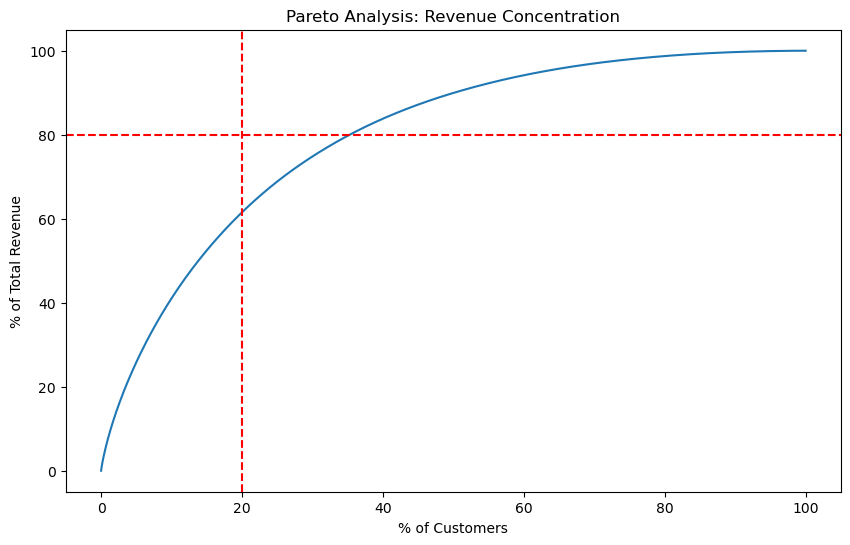

In [4]:
df_pareto = metrics.sort_values('net_monetary', ascending=False)
df_pareto['cum_sum'] = df_pareto['net_monetary'].cumsum()
df_pareto['cum_perc'] = 100 * df_pareto['cum_sum'] / df_pareto['net_monetary'].sum()
df_pareto['cust_perc'] = 100 * (pd.Series(range(1, len(df_pareto) + 1)) / len(df_pareto)).values

plt.figure(figsize=(10, 6))
sns.lineplot(x='cust_perc', y='cum_perc', data=df_pareto)
plt.axhline(80, color='r', linestyle='--')
plt.axvline(20, color='r', linestyle='--')
plt.title('Pareto Analysis: Revenue Concentration')
plt.xlabel('% of Customers')
plt.ylabel('% of Total Revenue')
plt.savefig(output_dir+"pareto_chart.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.2. Phân tích top 10 khách hàng chi trả nhiều nhất

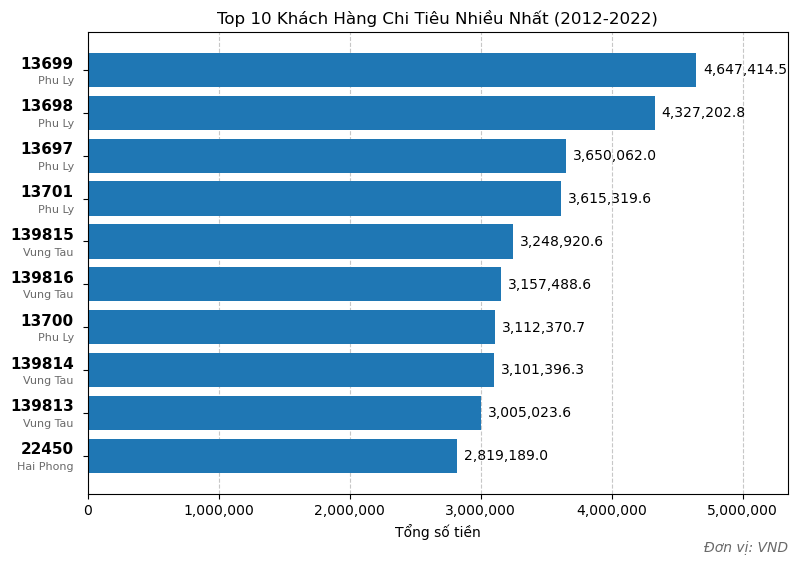

In [5]:
ranked=metrics.sort_values('net_monetary', ascending=False)
cutoff_index=int(len(ranked)*0.20)
top_ids = metrics.sort_values('net_monetary', ascending=False).head(cutoff_index).index
metrics['is_hvc'] = metrics.index.isin(top_ids)

vip_list=ranked.head(cutoff_index).copy()
final_hvc_report=pd.merge(vip_list, customers, on='customer_id')
final_hvc_report=pd.merge(final_hvc_report, geography, on='zip')
final_hvc_report=final_hvc_report.drop(columns=['city_y'])
final_hvc_report=final_hvc_report.rename(columns={'city_x': 'city'})

top10 = final_hvc_report[['customer_id', 'net_monetary', 'city']].head(10)

fig, ax = plt.subplots(figsize=(10, 6))

plt.subplots_adjust(left=0.2) 

y_positions = range(len(top10))
bars = ax.barh(y_positions, top10['net_monetary'])

ax.set_yticks(y_positions)
ax.set_yticklabels([]) 

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(-0.02, i - 0.15, str(row['customer_id']), 
            transform=ax.get_yaxis_transform(), 
            ha='right', va='center', fontsize=11, fontweight='bold')
    
    ax.text(-0.02, i + 0.25, row['city'], 
            transform=ax.get_yaxis_transform(), 
            ha='right', va='center', fontsize=8, color='dimgray')

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.bar_label(bars, fmt='{:,.1f}', padding=5)

ax.grid(True, axis='x', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax.set_xlabel('Tổng số tiền')
ax.set_title('Top 10 Khách Hàng Chi Tiêu Nhiều Nhất (2012-2022)')

ax.text(
    1.0, -0.1, 'Đơn vị: VND',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=10,
    fontstyle='italic',
    color='dimgray'
)

ax.invert_yaxis() 

ax.set_xlim(right=top10['net_monetary'].max() * 1.15) 
plt.savefig(output_dir+"top_10_monetary.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.3. So sánh giữa phần trăm khách hàng và phần trăm doanh thu

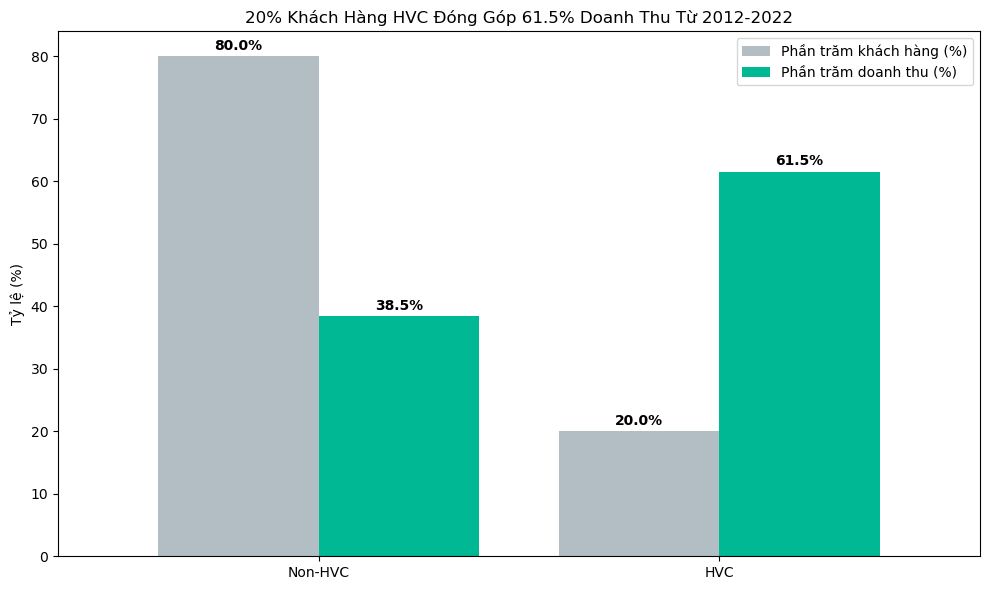

In [6]:
hvc_flat = metrics.reset_index()

gap_data = hvc_flat.groupby('is_hvc').agg({
    'customer_id': 'count',      # Now this column exists!
    'net_monetary': 'sum'
}).rename(columns={'customer_id': 'Customer_Count', 'net_monetary': 'Total_Revenue'})

gap_perc = gap_data.div(gap_data.sum(), axis=1) * 100
gap_perc.index = ['Non-HVC', 'HVC']

ax = gap_perc.plot(kind='bar', figsize=(10, 6), width=0.8, color=['#b2bec3', '#00b894'])

plt.title('20% Khách Hàng HVC Đóng Góp 61.5% Doanh Thu Từ 2012-2022')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(['Phần trăm khách hàng (%)', 'Phần trăm doanh thu (%)'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 1), 
                ha='center', weight='bold')

plt.tight_layout()
plt.savefig(output_dir+"hvc_pareto.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.4. Phân tích tỉ lệ các khách hàng tiềm năng (HVC) qua các kênh tiếp cận, giới tính và độ tuổi

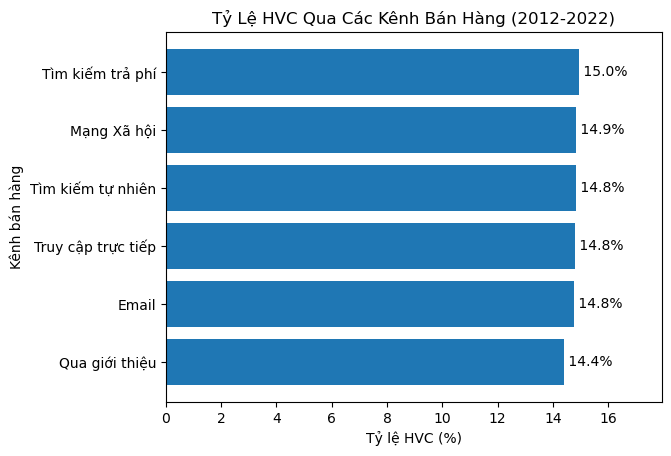

In [7]:
full_profile = pd.merge(customers, metrics[['is_hvc']], on='customer_id', how='left')
full_profile['is_hvc'] = (
    full_profile['is_hvc']
    .astype('boolean')
    .fillna(False)
)


channel_analysis = full_profile.pivot_table(
    index='acquisition_channel', 
    columns='is_hvc', 
    values='customer_id', 
    aggfunc='count', 
    fill_value=0
)

channel_analysis.columns = ['Standard_Cust', 'HVC_Cust']
channel_analysis['HVC_Rate_%'] = (channel_analysis['HVC_Cust'] / (channel_analysis['HVC_Cust'] + channel_analysis['Standard_Cust'])) * 100

channel_mapping = {
    'paid_search': 'Tìm kiếm trả phí',
    'social_media': 'Mạng Xã hội',
    'organic_search': 'Tìm kiếm tự nhiên',
    'direct': 'Truy cập trực tiếp',
    'email_campaign': 'Email',
    'referral': 'Qua giới thiệu'
}

channel_analysis = channel_analysis.rename(index=channel_mapping)

channel_sorted = channel_analysis.sort_values('HVC_Rate_%', ascending=True)

plt.figure()
plt.barh(channel_sorted.index, channel_sorted['HVC_Rate_%'])

plt.xlabel('Tỷ lệ HVC (%)')
plt.ylabel('Kênh bán hàng')
plt.title('Tỷ Lệ HVC Qua Các Kênh Bán Hàng (2012-2022)')
max_val = channel_sorted['HVC_Rate_%'].max()
plt.xlim(0, max_val * 1.2)
# Add labels
for i, v in enumerate(channel_sorted['HVC_Rate_%']):
    plt.text(v, i, f" {v:.1f}%", va='center')

plt.savefig(output_dir+"hvc_channel.png", dpi=300, bbox_inches='tight')
plt.show()

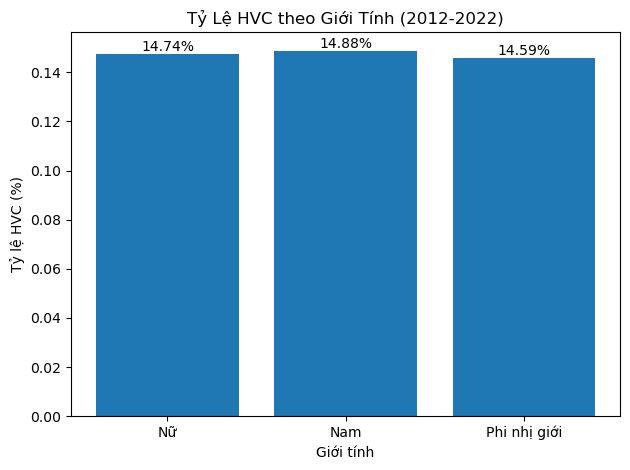

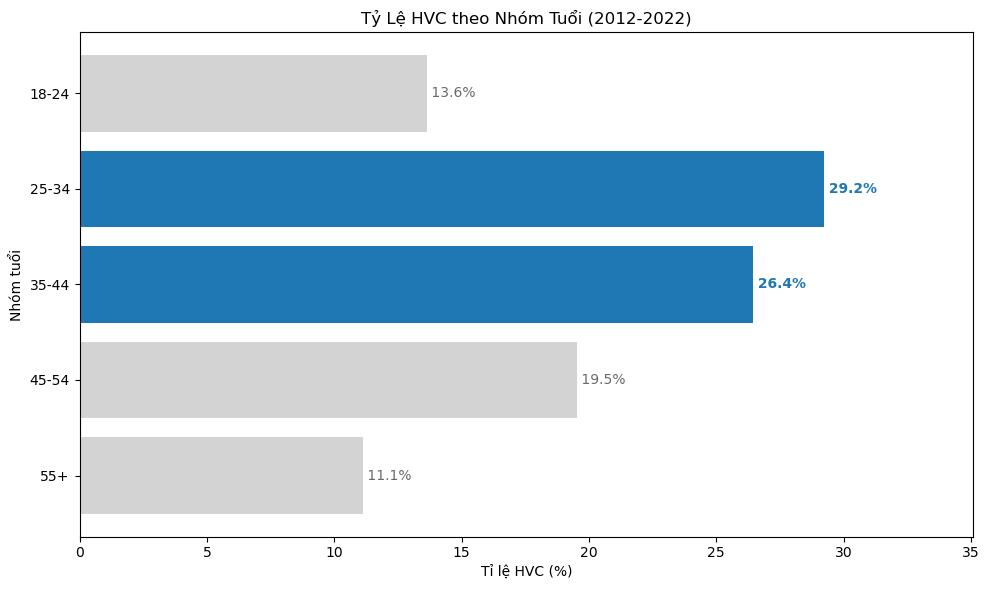

In [8]:
age_analysis = full_profile.pivot_table(
    index='age_group',
    columns='is_hvc',
    values='customer_id',
    aggfunc='count',
    fill_value=0
)
age_analysis.columns = ['Standard', 'HVC']
age_analysis['HVC_Concentration_%'] = (age_analysis['HVC'] / age_analysis['HVC'].sum()) * 100
gender_analysis = full_profile.pivot_table(
    index='gender', 
    columns='is_hvc', 
    values='customer_id', 
    aggfunc='count', 
    fill_value=0
)
gender_analysis.columns = ['Standard', 'HVC']
gender_analysis['HVC_Rate'] = gender_analysis['HVC'] / (gender_analysis['HVC'] + gender_analysis['Standard'])
gender_mapping = {
    'Male' : 'Nam',
    'Female': 'Nữ',
    'Non-binary': 'Phi nhị giới'
}

gender_analysis = gender_analysis.rename(index=gender_mapping)

gender_plot = gender_analysis.copy()

plt.figure()
plt.bar(gender_plot.index.astype(str), gender_plot['HVC_Rate'])

plt.xlabel('Giới tính')
plt.ylabel('Tỷ lệ HVC (%)')
plt.title('Tỷ Lệ HVC theo Giới Tính (2012-2022)')

for i, v in enumerate(gender_plot['HVC_Rate']):
    plt.text(i, v, f"{v:.2%}", ha='center', va='bottom')

plt.tight_layout()
plt.savefig(output_dir+"hvc_gender.png", dpi=300, bbox_inches='tight')
plt.show()

age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_plot = age_analysis.reindex(age_order)

top_2_threshold = age_plot['HVC_Concentration_%'].nlargest(2).min()

colors = ['#1f77b4' if v >= top_2_threshold else 'lightgray' for v in age_plot['HVC_Concentration_%']]

plt.figure(figsize=(10, 6))

bars = plt.barh(age_plot.index.astype(str), age_plot['HVC_Concentration_%'], color=colors)

plt.xlabel('Tỉ lệ HVC (%)')
plt.ylabel('Nhóm tuổi')
plt.title('Tỷ Lệ HVC theo Nhóm Tuổi (2012-2022)')

max_val = age_plot['HVC_Concentration_%'].max()
plt.xlim(0, max_val * 1.2)
plt.gca().invert_yaxis()

for i, v in enumerate(age_plot['HVC_Concentration_%']):
    text_color = '#1f77b4' if v >= top_2_threshold else 'dimgray'
    plt.text(v, i, f" {v:.1f}%", va='center', color=text_color, 
             fontweight='bold' if v >= top_2_threshold else 'normal')

plt.tight_layout()
plt.savefig(output_dir+"hvc_cohort.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.5. Phân tích mật độ HVC và thị trường theo thành phố

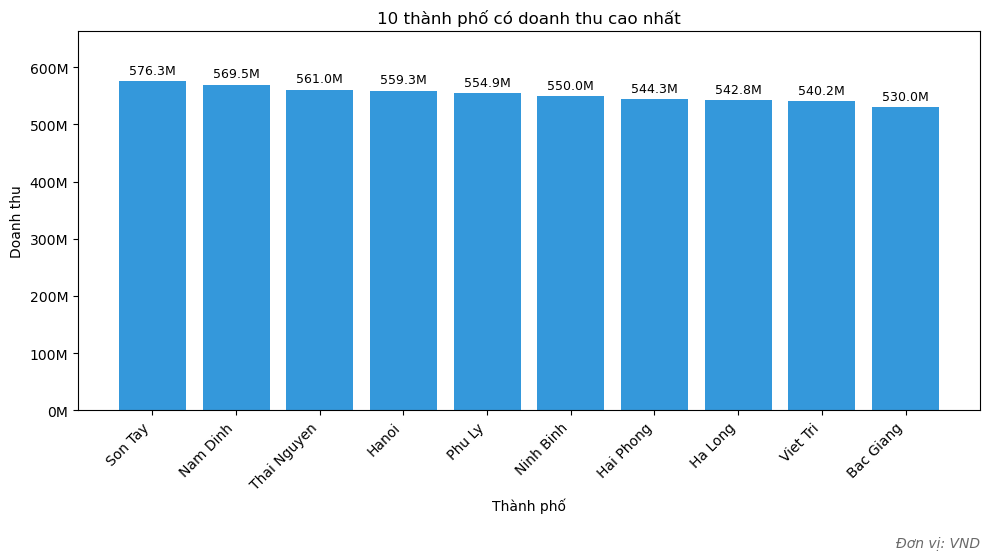

In [9]:
city_revenue = (
    master.assign(net_revenue=master['payment_value'] - master['refund_amount'].fillna(0))
          .groupby('city', observed=True)['net_revenue']
          .sum()
          .reset_index()
          .sort_values('net_revenue', ascending=False)
)

top_cities = city_revenue.head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(top_cities['city'], top_cities['net_revenue'], color='#3498db')

ax.set_xlabel('Thành phố')
ax.set_ylabel('Doanh thu')
ax.set_title('10 thành phố có doanh thu cao nhất')

plt.xticks(rotation=45, ha='right')

def millions_formatter(x, pos):
    return f'{x / 1e6:,.0f}M'

ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

custom_labels = [f'{val / 1e6:,.1f}M' for val in top_cities['net_revenue']]
ax.bar_label(bars, labels=custom_labels, padding=3, fontsize=9, color='black')

ax.set_ylim(top=top_cities['net_revenue'].max() * 1.15)

ax.annotate('Đơn vị: VND', xy=(1.0, -0.35), xycoords='axes fraction',
            ha='right', va='center', fontsize=10, fontstyle='italic', color='dimgray')

plt.tight_layout()
plt.show()

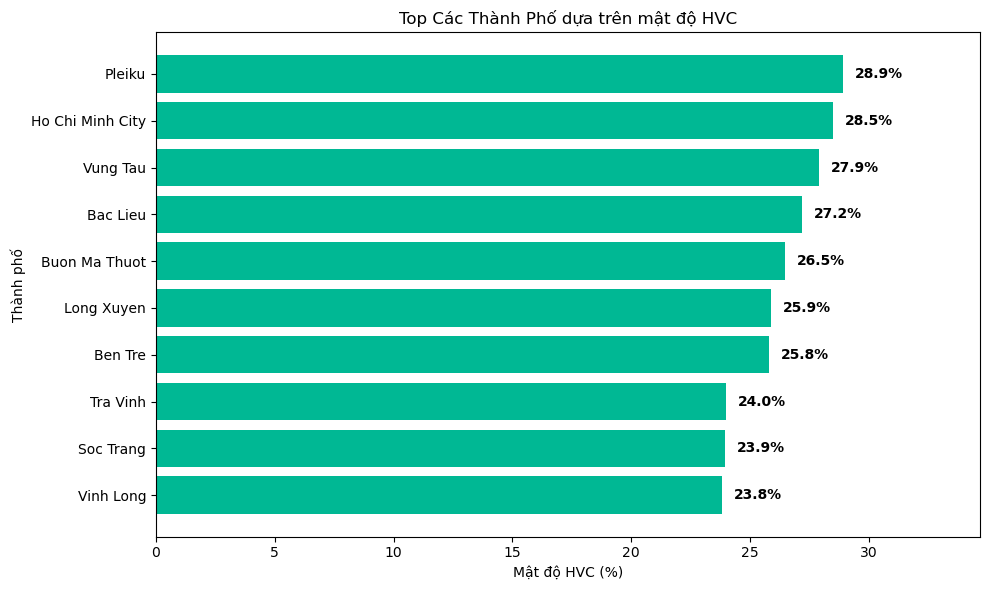

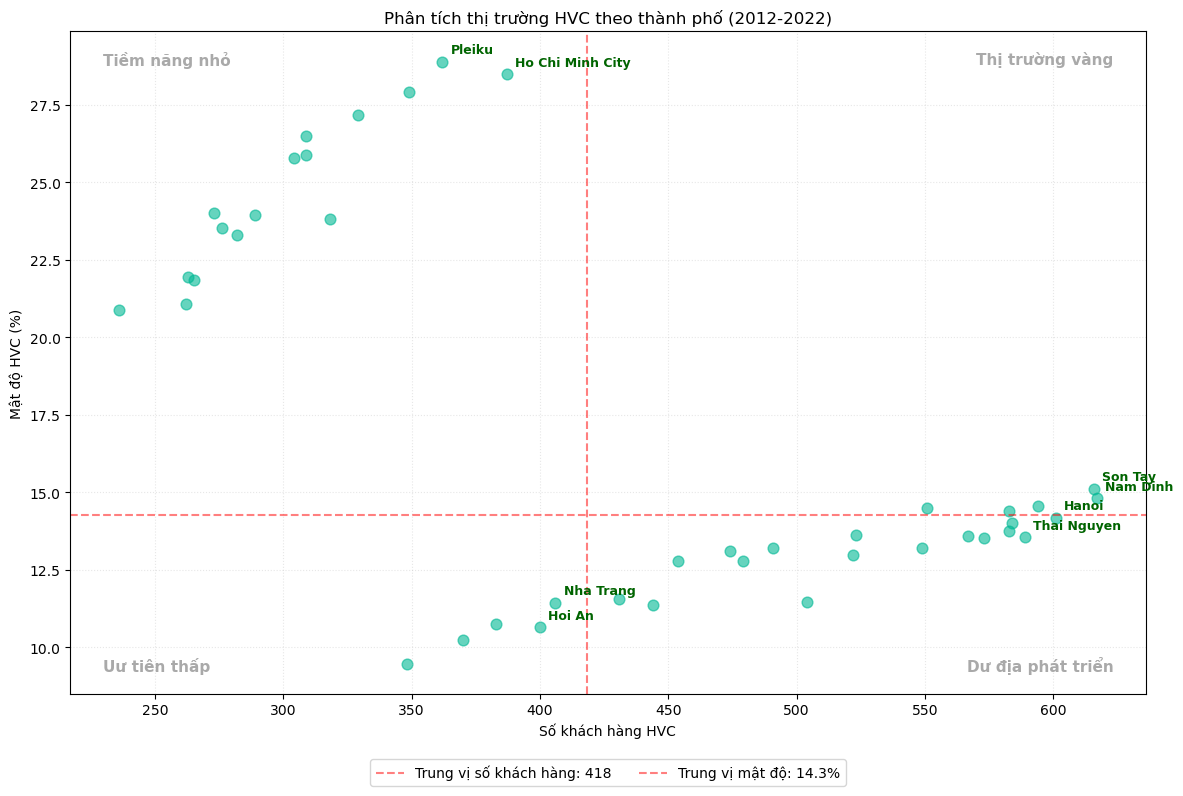

In [10]:
geo_profile=pd.merge(full_profile, geography, on='zip')
city_hvc_trend=geo_profile.groupby('city_x').agg({
    'is_hvc': 'sum',
    'customer_id': 'count'
}).rename(columns={'is_hvc': 'HVC_Count', 'customer_id': 'Total_Cust'})

city_hvc_trend['HVC_Density_%']=(city_hvc_trend['HVC_Count'])/(city_hvc_trend['Total_Cust'])*100

top_cities = city_hvc_trend.sort_values('HVC_Density_%', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_cities.index.astype(str), top_cities['HVC_Density_%'], color='#00b894')

plt.gca().invert_yaxis() 

plt.xlabel('Mật độ HVC (%)')
plt.ylabel('Thành phố')
plt.title('Top Các Thành Phố dựa trên mật độ HVC')

max_val = city_hvc_trend['HVC_Density_%'].max()
plt.xlim(0, max_val * 1.2)

for i, v in enumerate(top_cities['HVC_Density_%']):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir+"hvc_city_density.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 8))
plt.scatter(city_hvc_trend['HVC_Count'], city_hvc_trend['HVC_Density_%'], alpha=0.6, color='#00b894', s=60)
plt.xlabel('Số khách hàng HVC')
plt.ylabel('Mật độ HVC (%)')
plt.title('Phân tích thị trường HVC theo thành phố (2012-2022)')

median_count = city_hvc_trend['HVC_Count'].median()
median_density = city_hvc_trend['HVC_Density_%'].median()

min_x, max_x = plt.xlim()
min_y, max_y = plt.ylim()

plt.axvline(x=median_count, color='red', linestyle='--', alpha=0.5, label=f'Trung vị số khách hàng: {median_count:.0f}')
plt.axhline(y=median_density, color='red', linestyle='--', alpha=0.5, label=f'Trung vị mật độ: {median_density:.1f}%')

offset_x = (max_x - min_x) * 0.03
offset_y = (max_y - min_y) * 0.03

plt.text(min_x + offset_x, max_y - offset_y,
         'Tiềm năng nhỏ', color='darkgrey', fontsize=11, fontweight='bold', ha='left', va='top')
plt.text(max_x - offset_x, max_y - offset_y,
         'Thị trường vàng', color='darkgrey', fontsize=11, fontweight='bold', ha='right', va='top')
plt.text(max_x - offset_x, min_y + offset_y,
         'Dư địa phát triển', color='darkgrey', fontsize=11, fontweight='bold', ha='right', va='bottom')
plt.text(min_x + offset_x, min_y + offset_y,
         'Uư tiên thấp', color='darkgrey', fontsize=11, fontweight='bold', ha='left', va='bottom')

high_density = city_hvc_trend['HVC_Density_%'] > median_density
high_count   = city_hvc_trend['HVC_Count']     > median_count

quadrants = {
    'Golden':       (city_hvc_trend[ high_density &  high_count], 'darkgreen', 'HVC_Density_%'),
    'Potential':    (city_hvc_trend[ high_density & ~high_count], 'darkgreen',      'HVC_Density_%'),
    'Growth':       (city_hvc_trend[~high_density &  high_count], 'darkgreen',    'HVC_Count'),
    'Low Priority': (city_hvc_trend[~high_density & ~high_count], 'darkgreen',       'HVC_Count'),
}

for label, (df, color, sort_col) in quadrants.items():
    if not df.empty:
        top_cities = df.nlargest(2, sort_col)
        for idx, row in top_cities.iterrows():
            plt.annotate(
                idx,
                (row['HVC_Count'], row['HVC_Density_%']),
                textcoords="offset points", xytext=(6, 6),
                ha='left', fontsize=9, fontweight='bold', color=color
            )

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.grid(True, which='both', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir + "hvc_city_quadrant.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.6. Phân tích chi tiêu của các nhóm khách hàng trên từng quadrant về Danh mục (Category) và Phân khúc sản phẩm (Segment)

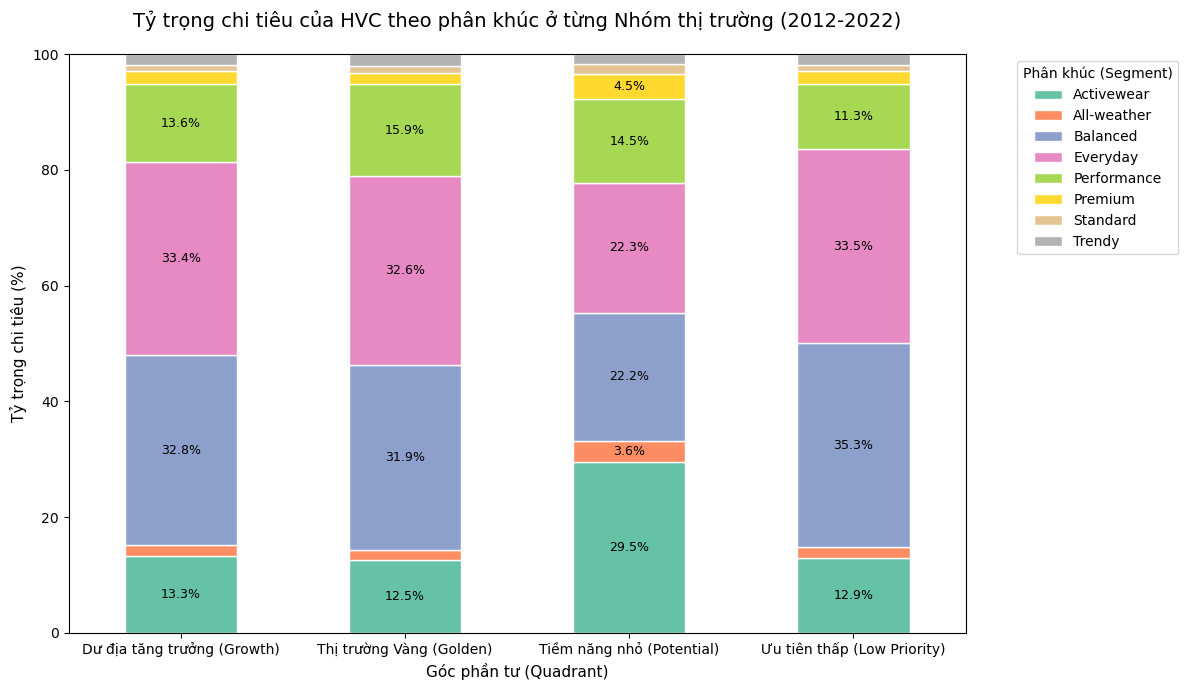

In [11]:
median_count = city_hvc_trend['HVC_Count'].median()
median_density = city_hvc_trend['HVC_Density_%'].median()

def assign_quadrant(row):
    if row['HVC_Count'] > median_count and row['HVC_Density_%'] > median_density:
        return 'Thị trường Vàng (Golden)'
    elif row['HVC_Count'] <= median_count and row['HVC_Density_%'] > median_density:
        return 'Tiềm năng nhỏ (Potential)'
    elif row['HVC_Count'] > median_count and row['HVC_Density_%'] <= median_density:
        return 'Dư địa tăng trưởng (Growth)'
    else:
        return 'Ưu tiên thấp (Low Priority)'

city_hvc_trend['Quadrant'] = city_hvc_trend.apply(assign_quadrant, axis=1)
quadrant_mapping = city_hvc_trend[['Quadrant']].reset_index()
if 'city_x' in quadrant_mapping.columns:
    quadrant_mapping = quadrant_mapping.rename(columns={'city_x': 'city'})
elif 'index' in quadrant_mapping.columns:
    quadrant_mapping = quadrant_mapping.rename(columns={'index': 'city'})

fashion_fit = master.merge(
    products[['product_id', 'category', 'segment']],
    on='product_id',
    how='left'
)
fashion_fit = fashion_fit.merge(
    metrics[['is_hvc']],
    on='customer_id',
    how='left'
)
fashion_fit['is_hvc'] = fashion_fit['is_hvc'].fillna(False)

fashion_quadrant = fashion_fit.merge(quadrant_mapping, on='city', how='inner')

hvc_quadrant_data = fashion_quadrant[fashion_quadrant['is_hvc'] == True]

quadrant_segment_spend = hvc_quadrant_data.groupby(['Quadrant', 'segment'])['payment_value'].sum().reset_index()

pivot_df = quadrant_segment_spend.pivot(index='Quadrant', columns='segment', values='payment_value').fillna(0)

pivot_percentage = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))

pivot_percentage.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=1)

ax.set_xlabel('Góc phần tư (Quadrant)', fontsize=11)
ax.set_ylabel('Tỷ trọng chi tiêu (%)', fontsize=11)
ax.set_title('Tỷ trọng chi tiêu của HVC theo phân khúc ở từng Nhóm thị trường (2012-2022)', fontsize=14, pad=20)

plt.xticks(rotation=0)

ax.set_ylim(0, 100)

plt.legend(title='Phân khúc (Segment)', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 3 else "" for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='black')

plt.tight_layout()

plt.savefig(output_dir + "hvc_segment.png", dpi=300, bbox_inches='tight')
plt.show()

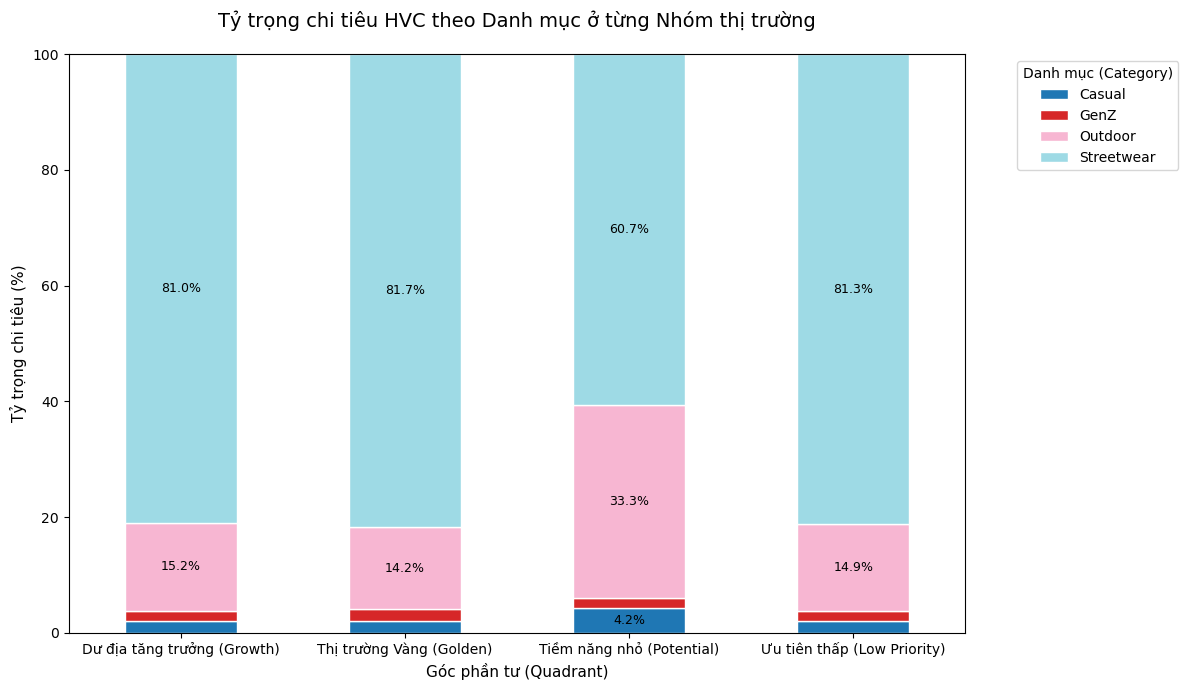

In [12]:
median_count = city_hvc_trend['HVC_Count'].median()
median_density = city_hvc_trend['HVC_Density_%'].median()

def assign_quadrant(row):
    if row['HVC_Count'] > median_count and row['HVC_Density_%'] > median_density:
        return 'Thị trường Vàng (Golden)'
    elif row['HVC_Count'] <= median_count and row['HVC_Density_%'] > median_density:
        return 'Tiềm năng nhỏ (Potential)'
    elif row['HVC_Count'] > median_count and row['HVC_Density_%'] <= median_density:
        return 'Dư địa tăng trưởng (Growth)'
    else:
        return 'Ưu tiên thấp (Low Priority)'

city_hvc_trend['Quadrant'] = city_hvc_trend.apply(assign_quadrant, axis=1)
quadrant_mapping = city_hvc_trend[['Quadrant']].reset_index()
if 'city_x' in quadrant_mapping.columns:
    quadrant_mapping = quadrant_mapping.rename(columns={'city_x': 'city'})
elif 'index' in quadrant_mapping.columns:
    quadrant_mapping = quadrant_mapping.rename(columns={'index': 'city'})

fashion_fit = master.merge(
    products[['product_id', 'category', 'segment']],
    on='product_id',
    how='left'
)
fashion_fit = fashion_fit.merge(
    metrics[['is_hvc']],
    on='customer_id',
    how='left'
)
fashion_fit['is_hvc'] = fashion_fit['is_hvc'].fillna(False)

fashion_quadrant = fashion_fit.merge(quadrant_mapping, on='city', how='inner')
hvc_quadrant_data = fashion_quadrant[fashion_quadrant['is_hvc'] == True]

quadrant_category_spend = hvc_quadrant_data.groupby(['Quadrant', 'category'])['payment_value'].sum().reset_index()
pivot_df = quadrant_category_spend.pivot(index='Quadrant', columns='category', values='payment_value').fillna(0)
pivot_percentage = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
pivot_percentage.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white', linewidth=1)

ax.set_xlabel('Góc phần tư (Quadrant)', fontsize=11)
ax.set_ylabel('Tỷ trọng chi tiêu (%)', fontsize=11)
ax.set_title('Tỷ trọng chi tiêu HVC theo Danh mục ở từng Nhóm thị trường', fontsize=14, pad=20)

plt.xticks(rotation=0)
ax.set_ylim(0, 100)

plt.legend(title='Danh mục (Category)', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 3 else "" for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig(output_dir + "hvc_category.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. Phân tích về cách giữ chân các HVC hiện tại, đồng thời tìm thêm HVC mới

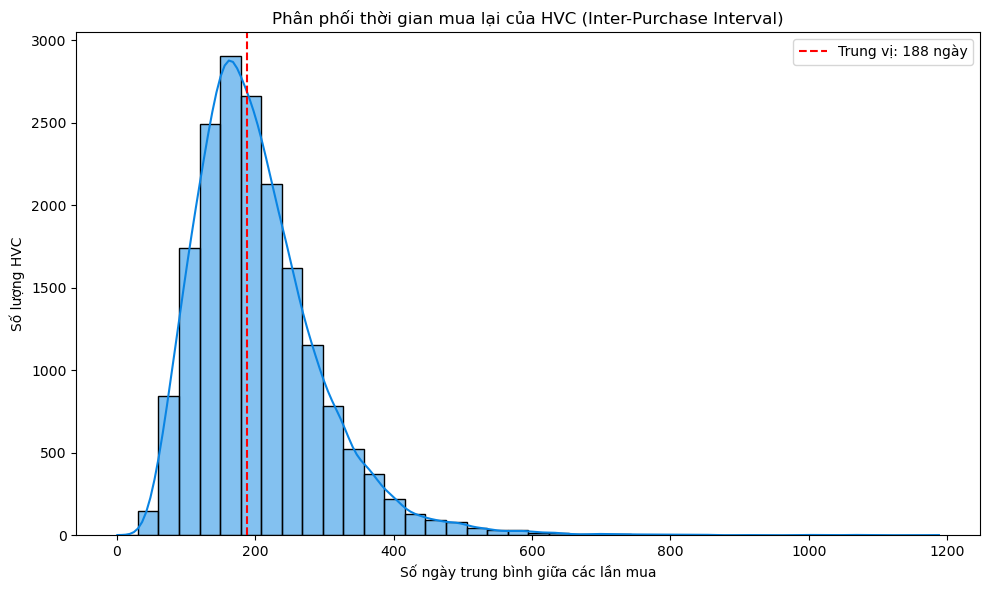

In [13]:
fashion_fit = master.merge(
    products[['product_id', 'category', 'segment']],
    on='product_id',
    how='left'
)
fashion_fit = fashion_fit.merge(
    metrics[['is_hvc']],
    on='customer_id',
    how='left'
)
fashion_fit['is_hvc'] = fashion_fit['is_hvc'].fillna(False)

fashion_fit['order_date'] = pd.to_datetime(fashion_fit['order_date'])

hvc_orders = fashion_fit[fashion_fit['is_hvc'] == True].copy()

unique_visits = hvc_orders.drop_duplicates(subset=['customer_id', 'order_id', 'order_date'])

unique_visits = unique_visits.sort_values(by=['customer_id', 'order_date'])

unique_visits['prev_order_date'] = unique_visits.groupby('customer_id')['order_date'].shift(1)

unique_visits['days_between'] = (unique_visits['order_date'] - unique_visits['prev_order_date']).dt.days

mean_interval_per_cust = unique_visits.groupby('customer_id')['days_between'].mean().dropna()

plt.figure(figsize=(10, 6))

sns.histplot(mean_interval_per_cust, bins=40, color='#0984e3', kde=True)

median_days = mean_interval_per_cust.median()

plt.axvline(median_days, color='red', linestyle='--', label=f'Trung vị: {median_days:.0f} ngày')

plt.xlabel('Số ngày trung bình giữa các lần mua')
plt.ylabel('Số lượng HVC')
plt.title('Phân phối thời gian mua lại của HVC (Inter-Purchase Interval)')
plt.legend()
plt.tight_layout()

plt.savefig(output_dir + "hvc_rebuy.png", dpi=300, bbox_inches='tight')
plt.show()

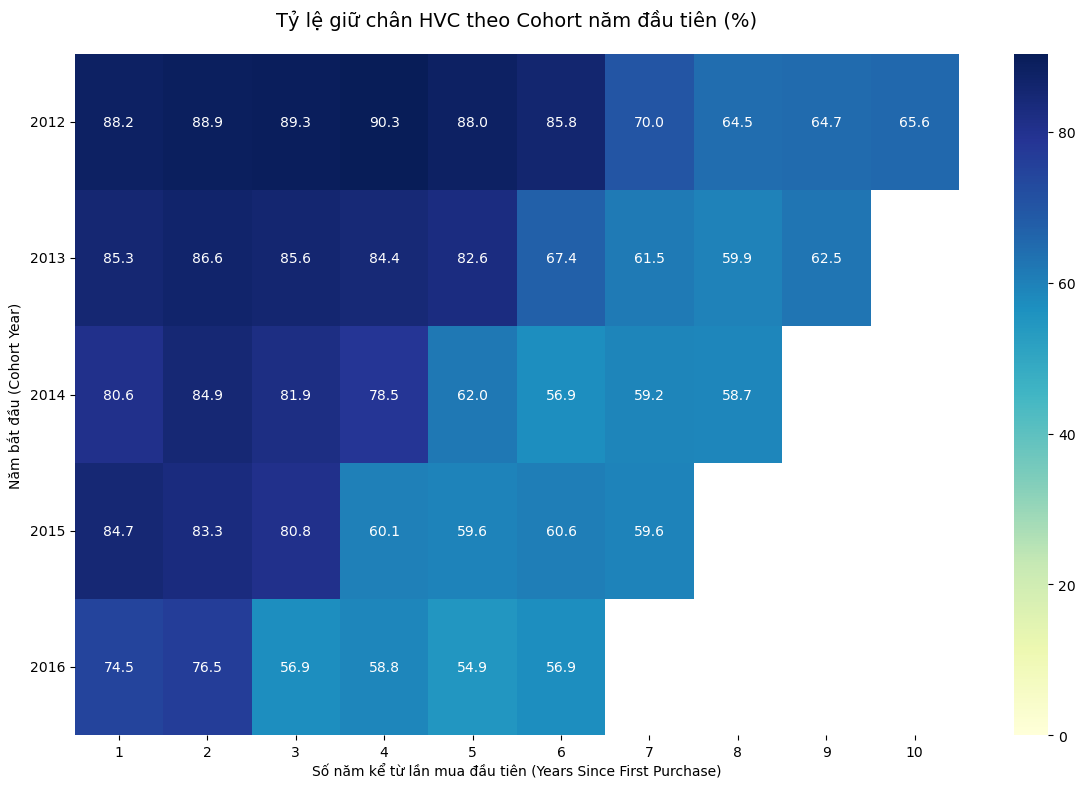

In [14]:
hvc_orders['order_year'] = hvc_orders['order_date'].dt.year

cohorts = hvc_orders.groupby('customer_id')['order_year'].min().reset_index()
cohorts.columns = ['customer_id', 'cohort_year']

hvc_retention = hvc_orders.merge(cohorts, on='customer_id')

hvc_retention['cohort_index'] = hvc_retention['order_year'] - hvc_retention['cohort_year']

cohort_data = hvc_retention.groupby(['cohort_year', 'cohort_index'])['customer_id'].nunique().reset_index()

# Pivot into a matrix format
cohort_pivot = cohort_data.pivot(index='cohort_year', columns='cohort_index', values='customer_id')

# 2. CALCULATE RETENTION PERCENTAGE
# Divide every column by the initial size of the cohort (Year 0)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.div(cohort_size, axis=0) * 100

# Chỉ giữ cohort có ít nhất 30 HVC
valid_cohorts = cohort_size[cohort_size >= 15].index
retention_matrix = retention_matrix.loc[valid_cohorts]

# 3. VISUALIZE AS A HEATMAP
plt.figure(figsize=(12, 8))
# We don't need to show Year 0 (which is always 100%), so we plot from Year 1 onward
sns.heatmap(retention_matrix.iloc[:, 1:], annot=True, fmt=".1f", cmap="YlGnBu", 
            vmin=0, vmax=retention_matrix.iloc[:, 1:].max().max())

plt.title('Tỷ lệ giữ chân HVC theo Cohort năm đầu tiên (%)', pad=20, fontsize=14)
plt.xlabel('Số năm kể từ lần mua đầu tiên (Years Since First Purchase)')
plt.ylabel('Năm bắt đầu (Cohort Year)')
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(output_dir + "hvc_retention_rate.png", dpi=300, bbox_inches='tight')
plt.show()

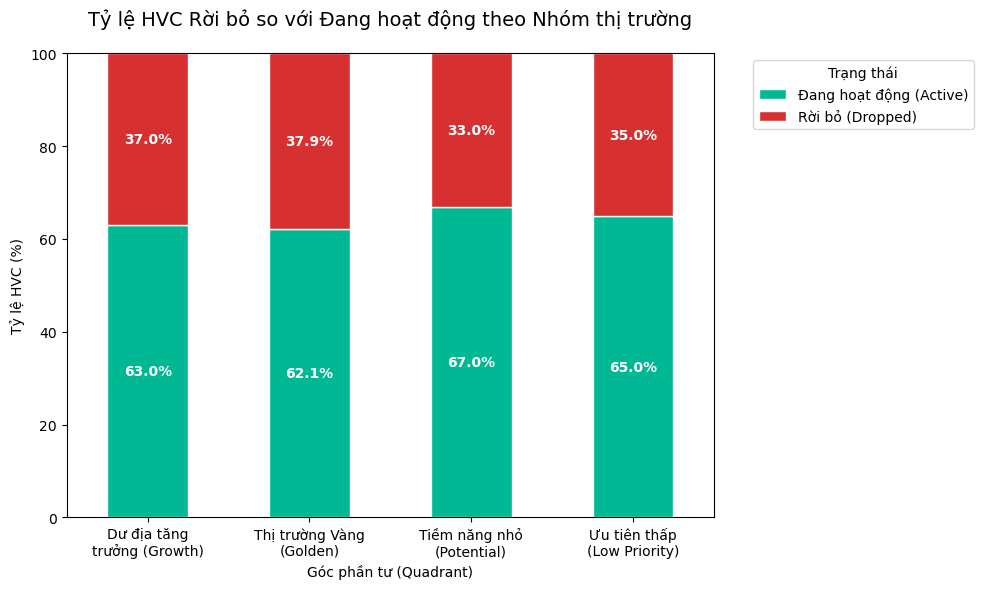

In [15]:
import textwrap
# Set the threshold for considering a customer "Dropped" (e.g., 365 days)
CHURN_THRESHOLD_DAYS = 365

# Assume 'today' is the most recent date in your entire dataset
latest_date = fashion_fit['order_date'].max()

hvc_orders_with_quadrant = hvc_orders.merge(quadrant_mapping, on='city', how='inner')
# -------------------------------------------------------

# 1. CALCULATE RECENCY & CHURN STATUS PER HVC
# Group by customer_id AND Quadrant using the fixed dataframe
recency_df = hvc_orders_with_quadrant.groupby(['customer_id', 'Quadrant'])['order_date'].max().reset_index()

# Calculate days since last purchase
recency_df['days_since_last'] = (latest_date - recency_df['order_date']).dt.days

# Tag them as Active or Dropped
recency_df['Status'] = recency_df['days_since_last'].apply(
    lambda x: 'Rời bỏ (Dropped)' if x > CHURN_THRESHOLD_DAYS else 'Đang hoạt động (Active)'
)

# 2. CALCULATE PROPORTIONS BY QUADRANT
# Count how many customers are in each status per quadrant
quadrant_churn = recency_df.groupby(['Quadrant', 'Status'])['customer_id'].count().reset_index()

# Pivot for the stacked bar chart
churn_pivot = quadrant_churn.pivot(index='Quadrant', columns='Status', values='customer_id').fillna(0)

# Convert absolute counts to 100% percentages
churn_pct = churn_pivot.div(churn_pivot.sum(axis=1), axis=0) * 100

# 3. VISUALIZE WITH A 100% STACKED BAR CHART
fig, ax = plt.subplots(figsize=(10, 6))

# Use Red for Dropped and Green/Teal for Active to make it instantly readable
colors = ['#00b894', '#d63031'] 

# Ensure columns are sorted so Active is first, Dropped is second
# (Only do this if both columns exist in the pivot to avoid a different KeyError)
available_cols = churn_pct.columns.tolist()
sorted_cols = [c for c in ['Đang hoạt động (Active)', 'Rời bỏ (Dropped)'] if c in available_cols]
churn_pct = churn_pct[sorted_cols] 

# Plot the chart
churn_pct.plot(kind='bar', stacked=True, ax=ax, color=colors[:len(sorted_cols)], edgecolor='white', linewidth=1)

ax.set_xlabel('Góc phần tư (Quadrant)')
ax.set_ylabel('Tỷ lệ HVC (%)')
ax.set_title('Tỷ lệ HVC Rời bỏ so với Đang hoạt động theo Nhóm thị trường', pad=20, fontsize=14)

wrapped_labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]
ax.set_xticklabels(wrapped_labels, rotation=0)
ax.set_ylim(0, 100)

# Move legend outside
plt.legend(title='Trạng thái', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels inside the bars
for c in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 0 else "" for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir + "hvc_churn_rate.png", dpi=300, bbox_inches='tight')
plt.show()


--- Biểu đồ Phân khúc ---


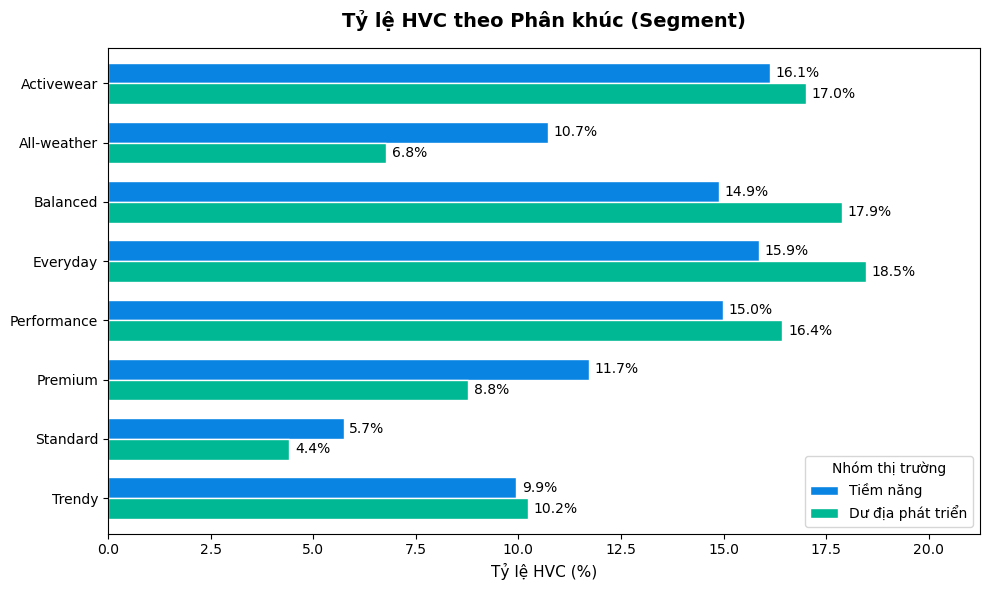


--- Biểu đồ Danh mục ---


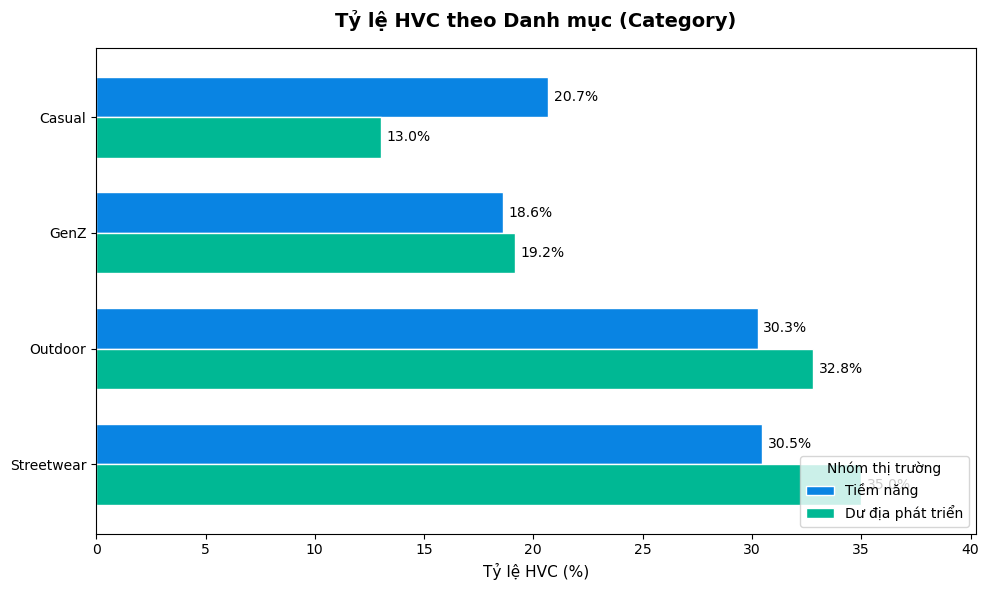


--- Biểu đồ Nhóm tuổi ---


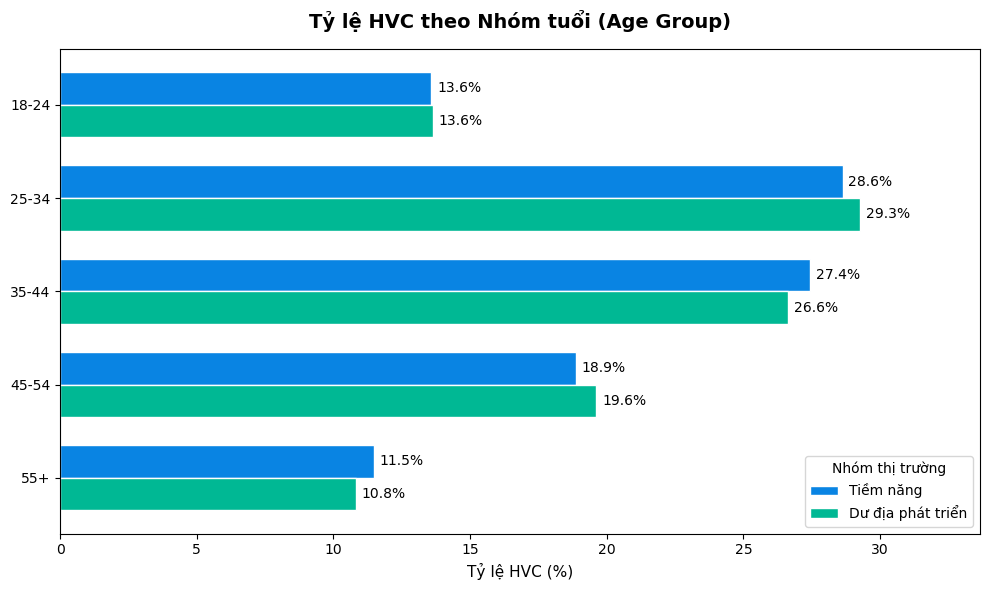

In [16]:
# 1. DEFINE THE TWO TARGET QUADRANTS
target_quadrants = ['Potential', 'Growth']

# 2. REBUILD CITY-QUADRANT MAPPING CLEANLY
median_count = city_hvc_trend['HVC_Count'].median()
median_density = city_hvc_trend['HVC_Density_%'].median()

def assign_quadrant(row):
    if row['HVC_Count'] > median_count and row['HVC_Density_%'] > median_density:
        return 'Golden'
    elif row['HVC_Count'] <= median_count and row['HVC_Density_%'] > median_density:
        return 'Potential'
    elif row['HVC_Count'] > median_count and row['HVC_Density_%'] <= median_density:
        return 'Growth'
    else:
        return 'Low Priority'

city_quadrants = city_hvc_trend.copy()
city_quadrants['Quadrant'] = city_quadrants.apply(assign_quadrant, axis=1)
city_quadrants = city_quadrants.reset_index()

if 'city_x' in city_quadrants.columns:
    city_quadrants = city_quadrants.rename(columns={'city_x': 'city'})
elif 'index' in city_quadrants.columns:
    city_quadrants = city_quadrants.rename(columns={'index': 'city'})

# 3. ATTACH QUADRANT INFO TO THE FASHION HVC DATA
fashion_profile = fashion_fit.copy()
if 'category' not in fashion_profile.columns or 'segment' not in fashion_profile.columns:
    fashion_profile = fashion_profile.merge(
        products[['product_id', 'category', 'segment']],
        on='product_id',
        how='left'
    )

fashion_profile = fashion_profile.merge(
    city_quadrants[['city', 'Quadrant']],
    on='city',
    how='left'
)

hvc_quadrant_data = fashion_profile[
    (fashion_profile['is_hvc'] == True) &
    (fashion_profile['Quadrant'].isin(target_quadrants))
].copy()

# Helper to compute and plot distribution
def plot_quadrant_distribution(feature, title, filename):
    counts = (
        hvc_quadrant_data
        .groupby(['Quadrant', feature])['customer_id']
        .nunique()
        .reset_index(name='count')
    )
    counts['total'] = counts.groupby('Quadrant')['count'].transform('sum')
    counts['percentage'] = counts['count'] / counts['total'] * 100

    pivot_df = counts.pivot(index=feature, columns='Quadrant', values='percentage').fillna(0)

    # Giữ nguyên thứ tự quadrant ban đầu để gán màu đúng
    quadrant_order = [q for q in target_quadrants if q in pivot_df.columns]
    pivot_df = pivot_df[quadrant_order]
    
    pivot_df = pivot_df.rename(columns={
        'Potential': 'Tiềm năng',
        'Growth': 'Dư địa phát triển'
    })

    # 2. Xử lý sắp xếp index (đặc biệt cho age_group)
    pivot_df = pivot_df.sort_index(ascending=True)
    # ---------------------------------------------- #

    # 3. Chuyển phần tạo figure vào trong hàm để in ra biểu đồ độc lập
    fig, ax = plt.subplots(figsize=(10, 6))

    # Vẽ biểu đồ
    pivot_df.plot(kind='barh', ax=ax, color=['#0984e3', '#00b894'], edgecolor='white', width=0.7)
    ax.set_title(title, fontsize=14, pad=15, fontweight='bold')
    ax.set_xlabel('Tỷ lệ HVC (%)', fontsize=11)
    ax.set_ylabel('')

    ax.invert_yaxis()

    for container in ax.containers:
        labels = [f"{v.get_width():.1f}%" if v.get_width() > 0 else "" for v in container]
        ax.bar_label(container, labels=labels, label_type='edge', padding=4, fontsize=10)

    ax.set_xlim(0, max(20, pivot_df.max().max() * 1.15))
    ax.legend(title='Nhóm thị trường', loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.savefig(output_dir + filename, dpi=300, bbox_inches='tight')
    plt.show()

# 4. GỌI HÀM 3 LẦN ĐỂ XUẤT RA 3 BIỂU ĐỒ RIÊNG BIỆT
print("\n--- Biểu đồ Phân khúc ---")
plot_quadrant_distribution('segment', 'Tỷ lệ HVC theo Phân khúc (Segment)', 'hvc_quadrant_segment_distribution.png')

print("\n--- Biểu đồ Danh mục ---")
plot_quadrant_distribution('category', 'Tỷ lệ HVC theo Danh mục (Category)', 'hvc_quadrant_category_distribution.png')

print("\n--- Biểu đồ Nhóm tuổi ---")
plot_quadrant_distribution('age_group', 'Tỷ lệ HVC theo Nhóm tuổi (Age Group)', 'hvc_quadrant_agegroup_distribution.png')

HVC rate and lifetime value by acquisition channel
         channel_name  Total_Customers  HVC_Customers  HVC_Rate_%  \
3    Tìm kiếm trả phí            24285           3631       14.95   
5         Mạng Xã hội            24448           3631       14.85   
2   Tìm kiếm tự nhiên            36450           5405       14.83   
0  Truy cập trực tiếp             9803           1451        14.8   
1               Email            14674           2165       14.75   
4      Qua giới thiệu            12270           1766       14.39   

   Avg_HVC_LTV  Avg_All_LTV  
3    564293.87    183564.81  
5    568262.63    185921.22  
2    567015.26    184888.83  
0    556976.80    180822.40  
1    565008.03    182006.63  
4    569445.46    182343.29  


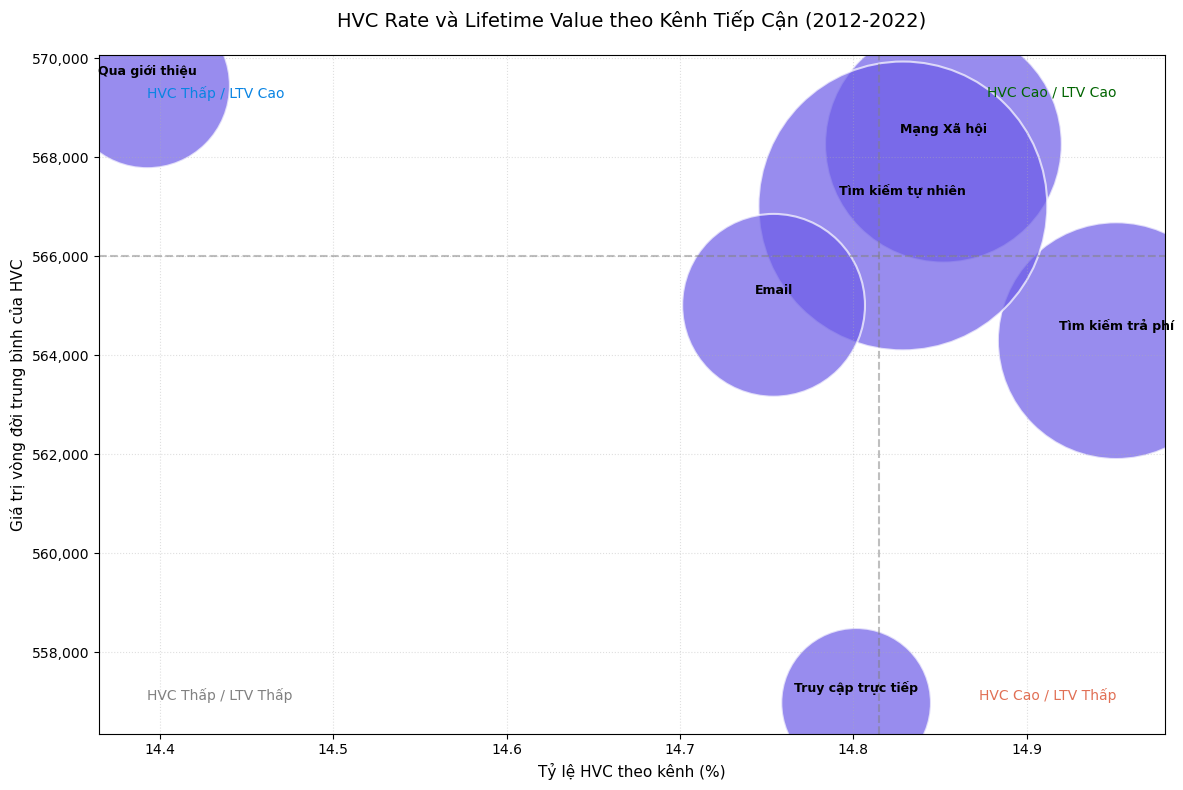

In [17]:
# 1. PREPARE THE CHANNEL METRICS
channel_data = full_profile.merge(metrics[['net_monetary']], on='customer_id', how='left')

channel_metrics = channel_data.groupby('acquisition_channel').agg(
    Total_Customers=('customer_id', 'count'),
    HVC_Customers=('is_hvc', 'sum')
).reset_index()

channel_metrics['HVC_Rate_%'] = channel_metrics['HVC_Customers'] / channel_metrics['Total_Customers'] * 100

# Average lifetime value for HVCs and all customers
hvc_ltv = (
    channel_data[channel_data['is_hvc'] == True]
    .groupby('acquisition_channel')['net_monetary']
    .mean()
    .rename('Avg_HVC_LTV')
)
all_ltv = (
    channel_data
    .groupby('acquisition_channel')['net_monetary']
    .mean()
    .rename('Avg_All_LTV')
)

channel_metrics = channel_metrics.set_index('acquisition_channel').join(hvc_ltv).join(all_ltv).reset_index()

# Sort channels for presentation
channel_mapping = {
    'paid_search': 'Tìm kiếm trả phí',
    'social_media': 'Mạng Xã hội',
    'organic_search': 'Tìm kiếm tự nhiên',
    'direct': 'Truy cập trực tiếp',
    'email_campaign': 'Email',
    'referral': 'Qua giới thiệu'
}
channel_metrics['channel_name'] = channel_metrics['acquisition_channel'].map(channel_mapping).fillna(channel_metrics['acquisition_channel'])
channel_metrics = channel_metrics.sort_values('HVC_Rate_%', ascending=False)

print('HVC rate and lifetime value by acquisition channel')
print(channel_metrics[['channel_name', 'Total_Customers', 'HVC_Customers', 'HVC_Rate_%', 'Avg_HVC_LTV', 'Avg_All_LTV']].round(2))

# 2. PLOT THE CHANNEL QUALITY MATRIX
fig, ax = plt.subplots(figsize=(12, 8))

x = channel_metrics['HVC_Rate_%']
y = channel_metrics['Avg_HVC_LTV']

# Use HVC customer count as bubble size
sizes = channel_metrics['HVC_Customers'] * 8
ax.scatter(x, y, s=sizes, color='#6c5ce7', alpha=0.7, edgecolors='white', linewidth=1.5)

for _, row in channel_metrics.iterrows():
    ax.annotate(
        row['channel_name'],
        (row['HVC_Rate_%'], row['Avg_HVC_LTV']),
        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9,
        fontweight='bold'
    )

x_mid = x.median()
y_mid = y.median()
ax.axvline(x=x_mid, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=y_mid, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Tỷ lệ HVC theo kênh (%)', fontsize=11)
ax.set_ylabel('Giá trị vòng đời trung bình của HVC', fontsize=11)
ax.set_title('HVC Rate và Lifetime Value theo Kênh Tiếp Cận (2012-2022)', fontsize=14, pad=20)

# Apply nicer formatting for y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'{val:,.0f}'))

# Add quadrant labels for quick interpretation
ax.text(x.max(), y.max(), 'HVC Cao / LTV Cao', ha='right', va='top', color='darkgreen', fontsize=10)
ax.text(x.min(), y.max(), 'HVC Thấp / LTV Cao', ha='left', va='top', color='#0984e3', fontsize=10)
ax.text(x.max(), y.min(), 'HVC Cao / LTV Thấp', ha='right', va='bottom', color='#e17055', fontsize=10)
ax.text(x.min(), y.min(), 'HVC Thấp / LTV Thấp', ha='left', va='bottom', color='gray', fontsize=10)

plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(output_dir + 'channel_hvc_rate_ltv.png', dpi=300, bbox_inches='tight')
plt.show()